# EEG-to-ECoG PatchTST v4 | Pretrained Light EEG -> ECoG Fine-Tuning


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Imports


In [2]:
from contextlib import nullcontext
from importlib.metadata import PackageNotFoundError, version as package_version
from pathlib import Path
import json
import math
import os
import random
import transformers

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    precision_recall_curve,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from transformers import EarlyStoppingCallback, PatchTSTConfig, PatchTSTForClassification, Trainer, TrainingArguments, default_data_collator
from transformers.utils import is_accelerate_available
from transformers.utils.versions import require_version


## Pretrained EEG Model


### EEG Variable Naming

Use these naming conventions in the pretrained EEG stage:
- `pretrained_eeg_model_name`
- `pretrained_eeg_model`
- `pretrained_eeg_threshold`
- `context_length_eeg`
- `num_channels_eeg`

This notebook loads the saved Light EEG checkpoint from `Final_Code/Light_CE_EEG` and uses it as the starting point for ECoG fine-tuning.


### 1. Fine-Tuning Helpers


In [12]:
# This section defines only the reusable helpers needed for
# loading the pretrained EEG model and fine-tuning it on ECoG.

try:
    accelerate_version = package_version("accelerate")
except PackageNotFoundError:
    accelerate_version = "not installed"

print(
    f"torch={torch.__version__} | transformers={transformers.__version__} | accelerate={accelerate_version} | accelerate_available={is_accelerate_available()}"
)

try:
    require_version("accelerate>=1.1.0")
except ImportError as exc:
    raise ImportError(
        "This notebook uses Hugging Face Trainer, which requires accelerate>=1.1.0 in the current Jupyter kernel. "
        "Install it with `%pip install -U 'accelerate>=1.1.0' 'transformers[torch]'`, then restart the kernel and rerun the notebook."
    ) from exc

if not is_accelerate_available():
    raise ImportError(
        "`accelerate` is installed, but `transformers` still reports it as unavailable in this kernel. "
        "This usually means `transformers` was imported before `accelerate` was installed or upgraded. "
        "Restart the Jupyter kernel completely, then rerun the notebook from the top."
    )


SEED = 42
TRAIN_BATCH_SIZE = int(os.environ.get("PATCHTST_TRAIN_BATCH_SIZE", 8))
EVAL_BATCH_SIZE = int(os.environ.get("PATCHTST_EVAL_BATCH_SIZE", 16))
GRADIENT_ACCUMULATION_STEPS = max(int(os.environ.get("PATCHTST_GRAD_ACCUM_STEPS", 1)), 1)
PRETRAINED_EEG_MODEL_DIR = Path(
    "/content/drive/MyDrive/Final_Code/PatchTst/Light_CE_EEG"
)
PRETRAINED_EEG_DEFAULT_THRESHOLD = float(os.environ.get("LIGHT_EEG_THRESHOLD", 0.85))
ECOG_FINETUNE_EPOCHS = int(os.environ.get("ECOG_FINETUNE_EPOCHS", 8))
ECOG_FINETUNE_LEARNING_RATE = float(os.environ.get("ECOG_FINETUNE_LEARNING_RATE", 5e-5))
ECOG_FINETUNE_WEIGHT_DECAY = float(os.environ.get("ECOG_FINETUNE_WEIGHT_DECAY", 1e-2))
HF_TRAINER_OUTPUT_DIR = Path(os.environ.get("HF_TRAINER_OUTPUT_DIR", "/tmp/patchtst_ecog_trainer"))
FINETUNED_ECOG_MODEL_DIR = Path(
    os.environ.get("FINETUNED_ECOG_MODEL_DIR", str(Path.cwd() / "PatchTst" / "finetuned_models" / "light_ecog"))
)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = device.type == "cuda"
AMP_ENABLED = device.type == "cuda" and os.environ.get("PATCHTST_USE_AMP", "1") == "1"
AMP_DTYPE = torch.bfloat16 if device.type == "cuda" and torch.cuda.is_bf16_supported() else torch.float16
USE_TF32 = device.type == "cuda" and os.environ.get("PATCHTST_USE_TF32", "1") == "1"
DATALOADER_NUM_WORKERS = int(os.environ.get("PATCHTST_NUM_WORKERS", 2 if (os.cpu_count() or 0) > 2 else 0))
DATALOADER_PREFETCH_FACTOR = int(os.environ.get("PATCHTST_PREFETCH_FACTOR", 2))
print(f"Training device: {device}")
print(
    f"Mixed precision: {AMP_ENABLED} "
    f"(dtype={AMP_DTYPE if AMP_ENABLED else 'float32'}) | "
    f"gradient_accumulation_steps={GRADIENT_ACCUMULATION_STEPS}"
)
print(
    f"TF32={USE_TF32} | dataloader_num_workers={DATALOADER_NUM_WORKERS} "
    f"| prefetch_factor={DATALOADER_PREFETCH_FACTOR if DATALOADER_NUM_WORKERS > 0 else 'n/a'}"
)

if device.type == "cuda":
    torch.backends.cuda.matmul.allow_tf32 = USE_TF32
    torch.backends.cudnn.allow_tf32 = USE_TF32
    torch.backends.cudnn.benchmark = True
    if hasattr(torch, "set_float32_matmul_precision"):
        torch.set_float32_matmul_precision("high")


def autocast_context():
    if AMP_ENABLED:
        return torch.autocast(device_type="cuda", dtype=AMP_DTYPE)
    return nullcontext()


def _label_counts(y: np.ndarray) -> dict:
    labels, counts = np.unique(y, return_counts=True)
    return dict(zip(labels.tolist(), counts.tolist()))


def to_patchtst_layout(x: np.ndarray) -> np.ndarray:
    return np.transpose(x, (0, 2, 1)).astype(np.float32)


loader_common_kwargs = {
    "pin_memory": PIN_MEMORY,
    "num_workers": DATALOADER_NUM_WORKERS,
}
if DATALOADER_NUM_WORKERS > 0:
    loader_common_kwargs["persistent_workers"] = True
    loader_common_kwargs["prefetch_factor"] = DATALOADER_PREFETCH_FACTOR


def build_classification_loss(class_weights: torch.Tensor) -> nn.Module:
    return nn.CrossEntropyLoss(weight=class_weights)


def build_inverse_frequency_class_weights(class_counts: dict[int, int]) -> torch.Tensor:
    if 0 not in class_counts or 1 not in class_counts:
        raise ValueError(f"Expected both classes in class_counts, got {class_counts}")

    total_count = sum(class_counts.values())
    return torch.tensor(
        [
            total_count / (2.0 * class_counts[0]),
            total_count / (2.0 * class_counts[1]),
        ],
        dtype=torch.float32,
    )


def extract_logits(outputs) -> torch.Tensor:
    if hasattr(outputs, "prediction_logits"):
        return outputs.prediction_logits
    if hasattr(outputs, "logits"):
        return outputs.logits
    return outputs[0]


def positive_class_probabilities(logits: torch.Tensor) -> torch.Tensor:
    if logits.ndim == 1:
        return torch.sigmoid(logits)
    if logits.ndim == 2 and logits.shape[1] == 1:
        return torch.sigmoid(logits.squeeze(-1))
    if logits.ndim == 2 and logits.shape[1] >= 2:
        return torch.softmax(logits, dim=1)[:, 1]
    raise ValueError(f"Unexpected logits shape for binary classification: {tuple(logits.shape)}")


def compute_metrics_from_probs(y_true: np.ndarray, y_prob: np.ndarray, threshold: float) -> dict:
    y_pred = (y_prob >= threshold).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="binary",
        zero_division=0,
    )
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
    }


def evaluate_probabilities(model: nn.Module, loader: DataLoader, loss_fn: nn.Module | None = None):
    model.eval()
    all_probs, all_labels = [], []
    total_loss, total_count = 0.0, 0

    with torch.no_grad():
        for batch in loader:
            xb = batch["past_values"].to(device, non_blocking=PIN_MEMORY)
            yb = batch["labels"].to(device, non_blocking=PIN_MEMORY)
            with autocast_context():
                outputs = model(past_values=xb)
                logits = extract_logits(outputs)
                probs = positive_class_probabilities(logits)
                if loss_fn is not None:
                    batch_loss = loss_fn(logits, yb)

            all_probs.append(probs.float().cpu().numpy())
            all_labels.append(yb.cpu().numpy())

            if loss_fn is not None:
                total_loss += float(batch_loss.item()) * xb.size(0)
                total_count += xb.size(0)

    y_prob = np.concatenate(all_probs)
    y_true = np.concatenate(all_labels)
    avg_loss = (total_loss / total_count) if total_count > 0 else None
    return y_true, y_prob, avg_loss


def tune_threshold(y_true: np.ndarray, y_prob: np.ndarray) -> tuple[float, dict]:
    best_threshold = 0.5
    best_metrics = compute_metrics_from_probs(y_true, y_prob, threshold=0.5)

    for threshold in np.arange(0.05, 0.951, 0.01):
        metrics = compute_metrics_from_probs(y_true, y_prob, threshold=float(threshold))
        if metrics["f1"] > best_metrics["f1"]:
            best_threshold = float(threshold)
            best_metrics = metrics

    return best_threshold, best_metrics


def _softmax_np(logits: np.ndarray) -> np.ndarray:
    logits = logits - np.max(logits, axis=1, keepdims=True)
    exp = np.exp(logits)
    return exp / np.sum(exp, axis=1, keepdims=True)


def compute_binary_metrics(eval_pred):
    logits, labels = eval_pred
    if isinstance(logits, tuple):
        logits = logits[0]

    logits = np.array(logits)
    labels = np.array(labels).astype(int).reshape(-1)

    if logits.ndim == 1:
        logits = logits.reshape(-1, 1)
    if logits.shape[1] == 1:
        logits = np.hstack([-logits, logits])

    probs = _softmax_np(logits)
    preds = probs.argmax(axis=1)
    pos_scores = probs[:, 1] if probs.shape[1] > 1 else probs[:, 0]

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="binary",
        zero_division=0,
    )
    accuracy = accuracy_score(labels, preds)
    try:
        auroc = roc_auc_score(labels, pos_scores)
    except ValueError:
        auroc = float("nan")
    try:
        auprc = average_precision_score(labels, pos_scores)
    except ValueError:
        auprc = float("nan")

    return {
        "accuracy": float(accuracy),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "auroc": float(auroc) if not np.isnan(auroc) else 0.0,
        "auprc": float(auprc) if not np.isnan(auprc) else 0.0,
    }


def validate_patchtst_classifier_head(
    model: PatchTSTForClassification,
    expected_num_targets: int = 2,
) -> PatchTSTForClassification:
    configured_num_targets = getattr(model.config, "num_targets", None)
    if configured_num_targets != expected_num_targets:
        raise ValueError(
            "PatchTST classification head is misconfigured: "
            f"expected num_targets={expected_num_targets}, got {configured_num_targets}. "
            "This transformers version uses `num_targets` for classification heads."
        )

    head = getattr(model, "head", None)
    linear = getattr(head, "linear", None)
    actual_out_features = getattr(linear, "out_features", None)
    if actual_out_features != expected_num_targets:
        raise ValueError(
            "PatchTST classification head output dimension mismatch: "
            f"expected {expected_num_targets}, got {actual_out_features}."
        )

    return model


def clean_state_dict_keys(state_dict: dict[str, torch.Tensor]) -> dict[str, torch.Tensor]:
    return {key.replace("_orig_mod.", ""): value for key, value in state_dict.items()}


class WeightedPatchTSTTrainer(Trainer):
    def __init__(self, class_weights: torch.Tensor, **kwargs):
        self.class_weights = class_weights
        super().__init__(**kwargs)

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        kwargs.pop("num_items_in_batch", None)
        labels = inputs["target_values"] if "target_values" in inputs else inputs.get("labels")
        if labels is None:
            raise ValueError("Expected 'target_values' or 'labels' in inputs for loss computation.")
        outputs = model(**inputs)
        logits = extract_logits(outputs)
        loss_fct = torch.nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))
        loss = loss_fct(logits.view(-1, logits.size(-1)), labels.view(-1))
        return (loss, outputs) if return_outputs else loss


def extract_epoch_history(log_history: list[dict]) -> list[dict]:
    history = []
    pending_train_loss = None
    for entry in log_history:
        if "loss" in entry and "eval_loss" not in entry:
            pending_train_loss = float(entry["loss"])
        if "eval_loss" in entry:
            history.append(
                {
                    "epoch": float(entry.get("epoch", len(history) + 1)),
                    "train_loss": float(pending_train_loss) if pending_train_loss is not None else None,
                    "val_loss": float(entry["eval_loss"]),
                    "val_accuracy": float(entry.get("eval_accuracy", 0.0)),
                    "val_precision": float(entry.get("eval_precision", 0.0)),
                    "val_recall": float(entry.get("eval_recall", 0.0)),
                    "val_f1": float(entry.get("eval_f1", 0.0)),
                    "val_threshold": 0.5,
                }
            )
    return history


def build_training_arguments(
    num_epochs: int,
    learning_rate: float,
    weight_decay: float,
    fp16: bool,
    bf16: bool,
    tf32: bool,
) -> TrainingArguments:
    HF_TRAINER_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    return TrainingArguments(
        output_dir=str(HF_TRAINER_OUTPUT_DIR),
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
        num_train_epochs=num_epochs,
        learning_rate=learning_rate,
        weight_decay=weight_decay,
        eval_strategy="epoch",
        logging_strategy="steps",
        logging_steps=10,
        logging_first_step=True,
        save_strategy="no",
        report_to="none",
        remove_unused_columns=False,
        label_names=["target_values"],
        seed=SEED,
        fp16=AMP_ENABLED and AMP_DTYPE == torch.float16,
        bf16=AMP_ENABLED and AMP_DTYPE == torch.bfloat16,
        tf32=USE_TF32,
        dataloader_pin_memory=PIN_MEMORY,
        dataloader_num_workers=DATALOADER_NUM_WORKERS,
        dataloader_persistent_workers=DATALOADER_NUM_WORKERS > 0,
        optim="adamw_torch", # Explicitly use standard PyTorch AdamW optimizer
    )

torch=2.9.0+cpu | transformers=5.0.0 | accelerate=1.13.0 | accelerate_available=True
Training device: cpu
Mixed precision: False (dtype=float32) | gradient_accumulation_steps=1
TF32=False | dataloader_num_workers=2 | prefetch_factor=2


### 2. Load the Saved Light EEG Model

Run this cell to load the pretrained Light EEG PatchTST model from `Final_Code/Light_CE_EEG`. No EEG retraining or EEG checkpoint folder is used in this notebook.


In [18]:
# This section loads the pretrained Light EEG PatchTST model from:
# Final_Code/Light_CE_EEG
#
# It replaces the EEG training stage and provides the pretrained model
# and threshold used to initialize the ECoG fine-tuning stage.

if not PRETRAINED_EEG_MODEL_DIR.exists():
    raise FileNotFoundError(f"Light EEG model directory not found: {PRETRAINED_EEG_MODEL_DIR}")

pretrained_eeg_model = validate_patchtst_classifier_head(
    PatchTSTForClassification.from_pretrained(PRETRAINED_EEG_MODEL_DIR),
    expected_num_targets=2,
).to(device)
pretrained_eeg_model.eval()

pretrained_eeg_model_name = "light"
pretrained_eeg_threshold = float(PRETRAINED_EEG_DEFAULT_THRESHOLD)
pretrained_eeg_architecture = pretrained_eeg_model.config.to_dict()
context_length_eeg = int(pretrained_eeg_architecture.get("context_length", -1))
num_channels_eeg = int(pretrained_eeg_architecture.get("num_input_channels", -1))
num_targets_eeg = int(pretrained_eeg_architecture.get("num_targets", -1))

if context_length_eeg <= 0 or num_channels_eeg <= 0:
    raise ValueError(
        "The pretrained Light EEG model is missing required PatchTST shape metadata. "
        f"context_length={context_length_eeg}, num_input_channels={num_channels_eeg}"
    )
if num_targets_eeg != 2:
    raise ValueError(f"Expected a binary classifier with num_targets=2, got {num_targets_eeg}")

print("Loaded pretrained Light EEG model:")
print(f" - model_dir: {PRETRAINED_EEG_MODEL_DIR}")
print(f" - config_name: {pretrained_eeg_model_name}")
print(f" - context_length: {context_length_eeg}")
print(f" - num_input_channels: {num_channels_eeg}")
print(f" - patch_length: {pretrained_eeg_architecture['patch_length']}")
print(f" - d_model: {pretrained_eeg_architecture['d_model']}")
print(f" - num_hidden_layers: {pretrained_eeg_architecture['num_hidden_layers']}")
print(f" - threshold: {pretrained_eeg_threshold:.2f}")
print(f" - ECoG fine-tune epochs: {ECOG_FINETUNE_EPOCHS}")
print(f" - ECoG learning rate: {ECOG_FINETUNE_LEARNING_RATE}")
print(f" - ECoG weight decay: {ECOG_FINETUNE_WEIGHT_DECAY}")

Loading weights:   0%|          | 0/71 [00:00<?, ?it/s]

Loaded pretrained Light EEG model:
 - model_dir: /content/drive/MyDrive/Final_Code/PatchTst/Light_CE_EEG
 - config_name: light
 - context_length: 1600
 - num_input_channels: 3
 - patch_length: 16
 - d_model: 128
 - num_hidden_layers: 3
 - threshold: 0.85
 - ECoG fine-tune epochs: 8
 - ECoG learning rate: 5e-05
 - ECoG weight decay: 0.01


## Fine-Tuned ECoG Model


### ECoG Variable Naming

Use these naming conventions in the fine-tuning stage:
- `x_ecog_all`, `y_ecog_all`
- `x_ecog_train`, `y_ecog_train`
- `x_ecog_val`, `y_ecog_val`
- `x_ecog_test`, `y_ecog_test`
- `finetuned_ecog_model`
- `finetuned_ecog_threshold`
- `ecog_evaluation_outputs`
- `ecog_classification_metrics`
- `ecog_ranking_metrics`
- `ecog_curve_data`

This stage fine-tunes from the saved `pretrained_eeg_model` loaded from `Light_CE_EEG` using weighted cross-entropy.


### 1. Load the ECoG Data Using `Final_Code/Data_Preprocessing/ecog_data_split.ipynb`


#### Load and Split ECoG Tensors

This cell executes the ECoG loader and performs the stratified `75/15/10` split.


In [19]:
# Load the file
data = torch.load("/content/drive/MyDrive/Final_Code/Data_Preprocessing/ecog_tensors.pt",weights_only=False)

# Extract tensors
x_ecog_train = data["X_train"]
y_ecog_train = data["y_train"]
x_ecog_val = data["X_valid"]
y_ecog_val = data["y_valid"]
x_ecog_test  = data["X_test"]
y_ecog_test  = data["y_test"]


print("Split tensors:")
print(" - x_ecog_train:", x_ecog_train.shape)
print(" - y_ecog_train:", y_ecog_train.shape, _label_counts(y_ecog_train))
print(" - x_ecog_val:", x_ecog_val.shape)
print(" - y_ecog_val:", y_ecog_val.shape, _label_counts(y_ecog_val))
print(" - x_ecog_test:", x_ecog_test.shape)
print(" - y_ecog_test:", y_ecog_test.shape, _label_counts(y_ecog_test))


Split tensors:
 - x_ecog_train: (7008, 3, 1600)
 - y_ecog_train: (7008,) {0: 3953, 1: 3055}
 - x_ecog_val: (1401, 3, 1600)
 - y_ecog_val: (1401,) {0: 790, 1: 611}
 - x_ecog_test: (935, 3, 1600)
 - y_ecog_test: (935,) {0: 528, 1: 407}


### 2. Fine-Tuning the Saved Light EEG Model on ECoG


In [20]:
import torch

torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False

In [27]:
# This section fine-tunes the saved Light EEG PatchTST model on ECoG data.
# It keeps the transfer setup conservative by training only the head,
# embedder, positional encoder, and the last transformer layer.
# The Trainer output is written only to a temporary working directory,
# and no checkpoint folder is saved by this notebook.

required_ecog_finetune_vars = [
    "pretrained_eeg_model",
    "pretrained_eeg_model_name",
    "pretrained_eeg_threshold",
    "context_length_eeg",
    "num_channels_eeg",
    "x_ecog_train",
    "y_ecog_train",
    "x_ecog_val",
    "y_ecog_val",
    "x_ecog_test",
    "y_ecog_test",
    "to_patchtst_layout",
    "build_classification_loss",
    "build_inverse_frequency_class_weights",
    "extract_logits",
    "evaluate_probabilities",
    "tune_threshold",
    "WeightedPatchTSTTrainer",
    "build_training_arguments",
    "extract_epoch_history",
    "compute_binary_metrics",
    "clean_state_dict_keys",
    "loader_common_kwargs",
]
missing_ecog_finetune_vars = [name for name in required_ecog_finetune_vars if name not in globals()]
if missing_ecog_finetune_vars:
    raise RuntimeError(
        f"Missing required previous-section outputs: {missing_ecog_finetune_vars}. "
        "Run the pretrained EEG loading cell and ECoG loading cells first."
    )

init_eeg_model_name = pretrained_eeg_model_name
init_eeg_model = pretrained_eeg_model
init_eeg_threshold = float(pretrained_eeg_threshold)
init_source = str(PRETRAINED_EEG_MODEL_DIR)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Fine-tuning device: {device}")

for split_name, x_split, y_split in [
    ("train", x_ecog_train, y_ecog_train),
    ("val", x_ecog_val, y_ecog_val),
    ("test", x_ecog_test, y_ecog_test),
]:
    if x_split.ndim != 3:
        raise ValueError(f"Expected x_{split_name} to have 3 dimensions (N, channels, time), got {x_split.shape}")
    if x_split.shape[1] != 3:
        raise ValueError(f"Expected x_{split_name} to have 3 ECoG channels, got shape {x_split.shape}")
    if x_split.shape[2] != 1600:
        raise ValueError(f"Expected x_{split_name} to have time length 1600, got shape {x_split.shape}")
    if len(x_split) != len(y_split):
        raise ValueError(f"Mismatch between features and labels in {split_name}: {x_split.shape} vs {y_split.shape}")
    if not np.isin(y_split, [0, 1]).all():
        raise ValueError(f"Found non-binary ECoG labels in {split_name}: {np.unique(y_split)}")

context_length_ecog = x_ecog_train.shape[-1]
num_channels_ecog = x_ecog_train.shape[1]
if context_length_ecog != context_length_eeg or num_channels_ecog != num_channels_eeg:
    raise ValueError(
        "ECoG fine-tuning expects the same PatchTST input dimensions as the pretrained EEG model. "
        f"Got ECoG ({context_length_ecog}, {num_channels_ecog}) vs EEG ({context_length_eeg}, {num_channels_eeg})."
    )


class ECoGPatchTSTDataset(Dataset):
    def __init__(self, x: np.ndarray, y: np.ndarray):
        x_patchtst = to_patchtst_layout(x)
        if x_patchtst.ndim != 3:
            raise ValueError(f"PatchTST ECoG dataset expected 3D tensors, got {x_patchtst.shape}")
        self.x = torch.tensor(x_patchtst, dtype=torch.float32)
        self.y = torch.tensor(y.astype(np.int64), dtype=torch.long)

    def __len__(self) -> int:
        return len(self.y)

    def __getitem__(self, idx: int) -> dict:
        return {
            "past_values": self.x[idx],
            "labels": self.y[idx],
        }


class ECoGTrainerDataset(Dataset):
    def __init__(self, x: np.ndarray, y: np.ndarray):
        x_patchtst = to_patchtst_layout(x)
        if x_patchtst.ndim != 3:
            raise ValueError(f"PatchTST ECoG trainer dataset expected 3D tensors, got {x_patchtst.shape}")
        self.x = torch.tensor(x_patchtst, dtype=torch.float32)
        self.y = torch.tensor(y.astype(np.int64), dtype=torch.long)

    def __len__(self) -> int:
        return len(self.y)

    def __getitem__(self, idx: int) -> dict:
        return {
            "past_values": self.x[idx],
            "target_values": self.y[idx],
        }


train_ds_ecog = ECoGPatchTSTDataset(x_ecog_train, y_ecog_train)
val_ds_ecog = ECoGPatchTSTDataset(x_ecog_val, y_ecog_val)
test_ds_ecog = ECoGPatchTSTDataset(x_ecog_test, y_ecog_test)

train_trainer_ds_ecog = ECoGTrainerDataset(x_ecog_train, y_ecog_train)
val_trainer_ds_ecog = ECoGTrainerDataset(x_ecog_val, y_ecog_val)
test_trainer_ds_ecog = ECoGTrainerDataset(x_ecog_test, y_ecog_test)

ecog_train_label_counts = _label_counts(y_ecog_train)
train_loader_ecog = DataLoader(train_ds_ecog, batch_size=TRAIN_BATCH_SIZE, shuffle=True, **loader_common_kwargs)
val_loader_ecog = DataLoader(val_ds_ecog, batch_size=EVAL_BATCH_SIZE, shuffle=False, **loader_common_kwargs)
test_loader_ecog = DataLoader(test_ds_ecog, batch_size=EVAL_BATCH_SIZE, shuffle=False, **loader_common_kwargs)

print("ECoG splits ready for fine-tuning:")
print(" - train:", train_ds_ecog.x.shape, ecog_train_label_counts)
print(" - val  :", val_ds_ecog.x.shape, _label_counts(y_ecog_val))
print(" - test :", test_ds_ecog.x.shape, _label_counts(y_ecog_test))
print(f" - initialized from: {init_eeg_model_name}")
print(f" - EEG init threshold: {init_eeg_threshold:.2f}")
print(f" - source: {init_source}")
print(
    f" - trainer datasets: train={len(train_trainer_ds_ecog)}, "
    f"val={len(val_trainer_ds_ecog)}, test={len(test_trainer_ds_ecog)}"
)


def set_module_trainable(module: nn.Module, trainable: bool = True) -> None:
    for parameter in module.parameters():
        parameter.requires_grad = trainable


base_state_dict = {
    key: value.detach().cpu().clone()
    for key, value in clean_state_dict_keys(init_eeg_model.state_dict()).items()
}
base_config = PatchTSTConfig.from_dict(init_eeg_model.config.to_dict())


def build_finetune_ready_ecog_model() -> PatchTSTForClassification:
    ecog_model = validate_patchtst_classifier_head(
        PatchTSTForClassification(base_config),
        expected_num_targets=2,
    )
    ecog_model.load_state_dict(base_state_dict)

    for parameter in ecog_model.parameters():
        parameter.requires_grad = False

    set_module_trainable(ecog_model.head, True)
    set_module_trainable(ecog_model.model.encoder.embedder, True)
    set_module_trainable(ecog_model.model.encoder.positional_encoder, True)
    set_module_trainable(ecog_model.model.encoder.layers[-1], True)
    return ecog_model


ecog_model_for_summary = build_finetune_ready_ecog_model()
trainable_parameter_names = [name for name, parameter in ecog_model_for_summary.named_parameters() if parameter.requires_grad]
trainable_parameter_count = sum(parameter.numel() for parameter in ecog_model_for_summary.parameters() if parameter.requires_grad)
total_parameter_count = sum(parameter.numel() for parameter in ecog_model_for_summary.parameters())

print("Trainable modules for ECoG fine-tuning:")
print(" - head")
print(" - model.encoder.embedder")
print(" - model.encoder.positional_encoder")
print(" - model.encoder.layers[-1]")
print(f" - trainable parameters: {trainable_parameter_count:,} / {total_parameter_count:,}")
print(" - trainable parameter tensors:")
for name in trainable_parameter_names:
    print(f"   {name}")


def train_ecog_model() -> dict:
    print("\n=== ECoG fine-tuning | weighted cross entropy | Trainer ===")

    class_counts_ecog = _label_counts(y_ecog_train)
    class_weights_cpu = build_inverse_frequency_class_weights(class_counts_ecog)
    print(f" - train class counts={class_counts_ecog} | class_weights={class_weights_cpu.tolist()}")

    trainer = WeightedPatchTSTTrainer(
        class_weights=class_weights_cpu,
        model=build_finetune_ready_ecog_model(),
        args=build_training_arguments(
            num_epochs=ECOG_FINETUNE_EPOCHS,
            learning_rate=ECOG_FINETUNE_LEARNING_RATE,
            weight_decay=ECOG_FINETUNE_WEIGHT_DECAY,
            fp16=AMP_ENABLED and AMP_DTYPE == torch.float16,
            bf16=AMP_ENABLED and AMP_DTYPE == torch.bfloat16,
            tf32=USE_TF32,
        ),
        train_dataset=train_trainer_ds_ecog,
        eval_dataset=val_trainer_ds_ecog,
        compute_metrics=compute_binary_metrics,
        data_collator=default_data_collator,
    )

    trainer.train()
    history = extract_epoch_history(trainer.state.log_history)

    trainer.model.to(device)
    trainer.model.eval()
    loss_fn_ecog = build_classification_loss(class_weights=class_weights_cpu.to(device))
    y_val_true_ecog, y_val_prob_ecog, val_loss_ecog = evaluate_probabilities(
        trainer.model,
        val_loader_ecog,
        loss_fn=loss_fn_ecog,
    )
    tuned_threshold_ecog, val_metrics_ecog = tune_threshold(y_val_true_ecog, y_val_prob_ecog)

    if history:
        history[-1]["val_threshold"] = float(tuned_threshold_ecog)
        history[-1]["val_f1_tuned"] = float(val_metrics_ecog["f1"])

    final_state_dict = {
        key: value.detach().cpu().clone()
        for key, value in clean_state_dict_keys(trainer.model.state_dict()).items()
    }

    final_model = build_finetune_ready_ecog_model()
    final_model.load_state_dict(final_state_dict)
    final_model.to(device)
    final_model.eval()

    del trainer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return {
        "model": final_model,
        "history": history,
        "best_threshold": float(tuned_threshold_ecog),
        "best_val_loss": float(val_loss_ecog) if val_loss_ecog is not None else None,
        "best_val_metrics": {k: float(v) for k, v in val_metrics_ecog.items()},
    }


ecog_finetune_result = train_ecog_model()
ecog_finetune_runs = {
    "ce": {
        "history": ecog_finetune_result["history"],
        "best_threshold": ecog_finetune_result["best_threshold"],
        "best_val_loss": ecog_finetune_result["best_val_loss"],
        "best_val_metrics": ecog_finetune_result["best_val_metrics"],
    }
}
finetuning_history_ecog = ecog_finetune_result["history"]
finetuned_ecog_model = ecog_finetune_result["model"]
finetuned_ecog_threshold = ecog_finetune_result["best_threshold"]
best_finetuned_val_metrics = ecog_finetune_result["best_val_metrics"]
best_finetuned_val_loss = ecog_finetune_result["best_val_loss"]

print("\nBest ECoG fine-tuning result selected:")
print(f" - initialized_from: {init_eeg_model_name}")
print(f" - finetuned_ecog_threshold: {finetuned_ecog_threshold:.2f}")
print(f" - best_finetuned_val_metrics: {best_finetuned_val_metrics}")

FINETUNED_ECOG_MODEL_DIR.mkdir(parents=True, exist_ok=True)
finetuned_ecog_model.save_pretrained(FINETUNED_ECOG_MODEL_DIR)
finetuned_ecog_metadata = {
    "initialized_from": init_eeg_model_name,
    "pretrained_model_dir": str(PRETRAINED_EEG_MODEL_DIR),
    "finetuned_ecog_model_dir": str(FINETUNED_ECOG_MODEL_DIR),
    "finetuned_ecog_threshold": float(finetuned_ecog_threshold),
    "best_finetuned_val_loss": float(best_finetuned_val_loss) if best_finetuned_val_loss is not None else None,
    "best_finetuned_val_metrics": {k: float(v) for k, v in best_finetuned_val_metrics.items()},
    "history": finetuning_history_ecog,
}
finetuned_ecog_metadata_path = FINETUNED_ECOG_MODEL_DIR / "metadata.json"
finetuned_ecog_metadata_path.write_text(json.dumps(finetuned_ecog_metadata, indent=2))

print(f" - saved_model_dir: {FINETUNED_ECOG_MODEL_DIR}")
print(f" - saved_metadata_path: {finetuned_ecog_metadata_path}")


Fine-tuning device: cpu
ECoG splits ready for fine-tuning:
 - train: torch.Size([7008, 1600, 3]) {0: 3953, 1: 3055}
 - val  : torch.Size([1401, 1600, 3]) {0: 790, 1: 611}
 - test : torch.Size([935, 1600, 3]) {0: 528, 1: 407}
 - initialized from: light
 - EEG init threshold: 0.85
 - source: /content/drive/MyDrive/Final_Code/PatchTst/Light_CE_EEG
 - trainer datasets: train=7008, val=1401, test=935
Trainable modules for ECoG fine-tuning:
 - head
 - model.encoder.embedder
 - model.encoder.positional_encoder
 - model.encoder.layers[-1]
 - trainable parameters: 338,306 / 603,266
 - trainable parameter tensors:
   model.encoder.embedder.input_embedding.weight
   model.encoder.embedder.input_embedding.bias
   model.encoder.positional_encoder.position_enc
   model.encoder.layers.2.self_attn.k_proj.weight
   model.encoder.layers.2.self_attn.k_proj.bias
   model.encoder.layers.2.self_attn.v_proj.weight
   model.encoder.layers.2.self_attn.v_proj.bias
   model.encoder.layers.2.self_attn.q_proj.weig

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Auroc,Auprc
1,0.505447,0.416547,0.847966,0.795252,0.877250,0.834241,0.917901,0.885016
2,0.470798,0.365505,0.880086,0.857835,0.869067,0.863415,0.937687,0.908071
3,0.597769,0.350248,0.887223,0.844749,0.908347,0.875394,0.943476,0.916012
4,0.243184,0.352257,0.887223,0.856693,0.890344,0.873194,0.942074,0.911394
5,0.277145,0.349362,0.885796,0.847458,0.900164,0.873016,0.945214,0.919597
6,0.436744,0.336548,0.890079,0.847793,0.911620,0.878549,0.947814,0.923004
7,0.331024,0.336688,0.888651,0.849462,0.905074,0.876387,0.948204,0.924636
8,0.324226,0.337545,0.888651,0.859400,0.890344,0.874598,0.947406,0.922393



Best ECoG fine-tuning result selected:
 - initialized_from: light
 - finetuned_ecog_threshold: 0.42
 - best_finetuned_val_metrics: {'accuracy': 0.8915060670949322, 'precision': 0.8547140649149922, 'recall': 0.9050736497545008, 'f1': 0.8791732909379968}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

 - saved_model_dir: /content/PatchTst/finetuned_models/light_ecog
 - saved_metadata_path: /content/PatchTst/finetuned_models/light_ecog/metadata.json


### 3. Evaluation


In [28]:
# This section evaluates the fine-tuned ECoG PatchTST model on the train,
# validation, and test splits without updating model weights.
#
# It stores probabilities, labels, losses, and thresholded predictions so
# the later ECoG metric sections can reuse the same evaluation outputs.

required_ecog_eval_vars = [
    "finetuned_ecog_model",
    "finetuned_ecog_threshold",
    "train_loader_ecog",
    "val_loader_ecog",
    "test_loader_ecog",
    "compute_metrics_from_probs",
    "evaluate_probabilities",
]
missing_ecog_eval_vars = [name for name in required_ecog_eval_vars if name not in globals()]
if missing_ecog_eval_vars:
    raise RuntimeError(
        f"Missing section 2 outputs: {missing_ecog_eval_vars}. Run the ECoG fine-tuning cell first."
    )


split_loaders_ecog = {
    "train": train_loader_ecog,
    "val": val_loader_ecog,
    "test": test_loader_ecog,
}

ecog_evaluation_outputs = {}
ecog_evaluation_summary = {}

finetuned_ecog_model.eval()

for split_name, split_loader in split_loaders_ecog.items():
    y_true_split, y_prob_split, split_loss = evaluate_probabilities(finetuned_ecog_model, split_loader)
    metrics_at_best_threshold = compute_metrics_from_probs(
        y_true_split,
        y_prob_split,
        threshold=finetuned_ecog_threshold,
    )
    metrics_at_default_threshold = compute_metrics_from_probs(
        y_true_split,
        y_prob_split,
        threshold=0.50,
    )

    ecog_evaluation_outputs[split_name] = {
        "y_true": y_true_split,
        "y_prob": y_prob_split,
        "y_pred_best_threshold": (y_prob_split >= finetuned_ecog_threshold).astype(int),
        "y_pred_default_threshold": (y_prob_split >= 0.50).astype(int),
        "loss": float(split_loss) if split_loss is not None else None,
    }

    ecog_evaluation_summary[split_name] = {
        "threshold_used": float(finetuned_ecog_threshold),
        "loss": float(split_loss) if split_loss is not None else None,
        "metrics_at_best_threshold": metrics_at_best_threshold,
        "metrics_at_default_threshold": metrics_at_default_threshold,
        "num_samples": int(len(y_true_split)),
        "label_counts": _label_counts(y_true_split),
    }

print("ECoG evaluation completed using the fine-tuned model:")
print(f" - finetuned_ecog_threshold: {finetuned_ecog_threshold:.2f}")

for split_name, split_summary in ecog_evaluation_summary.items():
    best_metrics = split_summary["metrics_at_best_threshold"]
    print(f"\n[{split_name.upper()}]")
    print(f" - samples: {split_summary['num_samples']}")
    print(f" - label_counts: {split_summary['label_counts']}")
    if split_summary['loss'] is not None:
        print(f" - loss: {split_summary['loss']:.4f}")
    print(
        f" - metrics @ threshold {finetuned_ecog_threshold:.2f}: "
        f"accuracy={best_metrics['accuracy']:.4f}, "
        f"precision={best_metrics['precision']:.4f}, "
        f"recall={best_metrics['recall']:.4f}, "
        f"f1={best_metrics['f1']:.4f}"
    )


ECoG evaluation completed using the fine-tuned model:
 - finetuned_ecog_threshold: 0.42

[TRAIN]
 - samples: 7008
 - label_counts: {0: 3953, 1: 3055}
 - metrics @ threshold 0.42: accuracy=0.9014, precision=0.8597, recall=0.9247, f1=0.8910

[VAL]
 - samples: 1401
 - label_counts: {0: 790, 1: 611}
 - metrics @ threshold 0.42: accuracy=0.8915, precision=0.8547, recall=0.9051, f1=0.8792

[TEST]
 - samples: 935
 - label_counts: {0: 528, 1: 407}
 - metrics @ threshold 0.42: accuracy=0.8717, precision=0.8376, recall=0.8747, f1=0.8558


### 4. Accuracy, Precision, Recall, F1-Score


In [29]:
# This section reports the standard classification metrics at the
# selected decision threshold from ECoG section 2.

if "ecog_evaluation_summary" not in globals():
    raise RuntimeError("Run ECoG section 3 first to generate evaluation summaries.")


ecog_classification_metrics = {}

for split_name, split_summary in ecog_evaluation_summary.items():
    best_metrics = split_summary["metrics_at_best_threshold"]
    ecog_classification_metrics[split_name] = {
        "threshold": float(split_summary["threshold_used"]),
        "accuracy": float(best_metrics["accuracy"]),
        "precision": float(best_metrics["precision"]),
        "recall": float(best_metrics["recall"]),
        "f1_score": float(best_metrics["f1"]),
    }

print("ECoG accuracy, precision, recall, and F1-score at the selected threshold:")
for split_name, metrics_dict in ecog_classification_metrics.items():
    print(f"\n[{split_name.upper()}]")
    print(f" - threshold: {metrics_dict['threshold']:.2f}")
    print(f" - accuracy : {metrics_dict['accuracy']:.4f}")
    print(f" - precision: {metrics_dict['precision']:.4f}")
    print(f" - recall   : {metrics_dict['recall']:.4f}")
    print(f" - f1_score : {metrics_dict['f1_score']:.4f}")


ECoG accuracy, precision, recall, and F1-score at the selected threshold:

[TRAIN]
 - threshold: 0.42
 - accuracy : 0.9014
 - precision: 0.8597
 - recall   : 0.9247
 - f1_score : 0.8910

[VAL]
 - threshold: 0.42
 - accuracy : 0.8915
 - precision: 0.8547
 - recall   : 0.9051
 - f1_score : 0.8792

[TEST]
 - threshold: 0.42
 - accuracy : 0.8717
 - precision: 0.8376
 - recall   : 0.8747
 - f1_score : 0.8558


### 5. AUROC, AUPRC, and Confusion Matrices


In [30]:
# This section computes probability-based metrics and confusion matrices
# for train, validation, and test ECoG splits.

if "ecog_evaluation_outputs" not in globals():
    raise RuntimeError("Run ECoG section 3 first to generate evaluation outputs.")
if "ecog_evaluation_summary" not in globals():
    raise RuntimeError("Run ECoG section 3 first to generate evaluation summaries.")


ecog_ranking_metrics = {}

for split_name, split_outputs in ecog_evaluation_outputs.items():
    y_true = split_outputs["y_true"]
    y_prob = split_outputs["y_prob"]
    y_pred = split_outputs["y_pred_best_threshold"]
    split_threshold = float(ecog_evaluation_summary[split_name]["threshold_used"])

    try:
        auroc_value = float(roc_auc_score(y_true, y_prob))
    except ValueError:
        auroc_value = float("nan")

    try:
        auprc_value = float(average_precision_score(y_true, y_prob))
    except ValueError:
        auprc_value = float("nan")

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    ecog_ranking_metrics[split_name] = {
        "threshold": split_threshold,
        "auroc": auroc_value,
        "auprc": auprc_value,
        "confusion_matrix": cm,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

print("ECoG AUROC, AUPRC, and confusion matrices at the selected threshold:")
for split_name, metrics_dict in ecog_ranking_metrics.items():
    print(f"\n[{split_name.upper()}]")
    print(f" - threshold: {metrics_dict['threshold']:.2f}")
    print(f" - AUROC: {metrics_dict['auroc']:.4f}")
    print(f" - AUPRC: {metrics_dict['auprc']:.4f}")
    print(" - Confusion matrix [rows=true, cols=pred]:")
    print(metrics_dict["confusion_matrix"])
    print(
        f" - TN={metrics_dict['tn']}, FP={metrics_dict['fp']}, "
        f"FN={metrics_dict['fn']}, TP={metrics_dict['tp']}"
    )


ECoG AUROC, AUPRC, and confusion matrices at the selected threshold:

[TRAIN]
 - threshold: 0.42
 - AUROC: 0.9527
 - AUPRC: 0.9275
 - Confusion matrix [rows=true, cols=pred]:
[[3492  461]
 [ 230 2825]]
 - TN=3492, FP=461, FN=230, TP=2825

[VAL]
 - threshold: 0.42
 - AUROC: 0.9474
 - AUPRC: 0.9224
 - Confusion matrix [rows=true, cols=pred]:
[[696  94]
 [ 58 553]]
 - TN=696, FP=94, FN=58, TP=553

[TEST]
 - threshold: 0.42
 - AUROC: 0.9453
 - AUPRC: 0.9382
 - Confusion matrix [rows=true, cols=pred]:
[[459  69]
 [ 51 356]]
 - TN=459, FP=69, FN=51, TP=356


### 6. ROC and Precision-Recall Curves


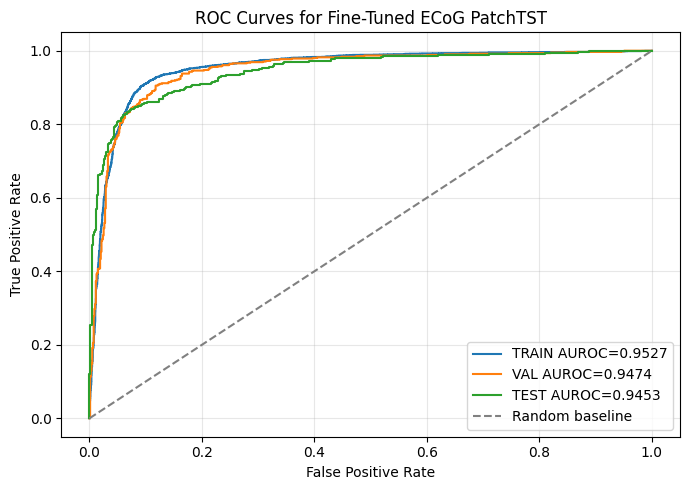

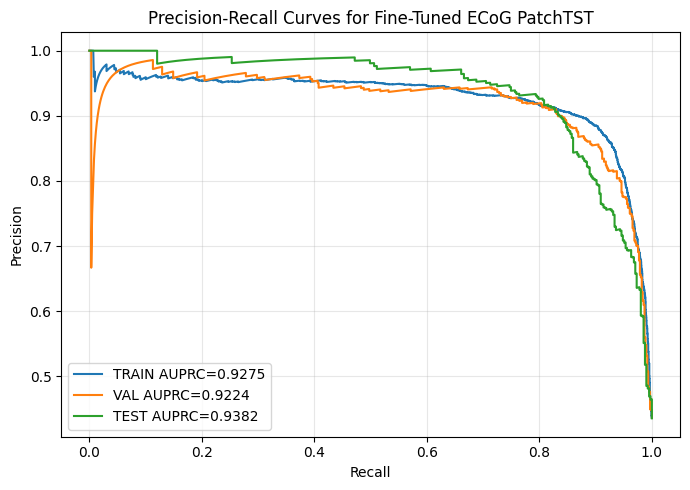

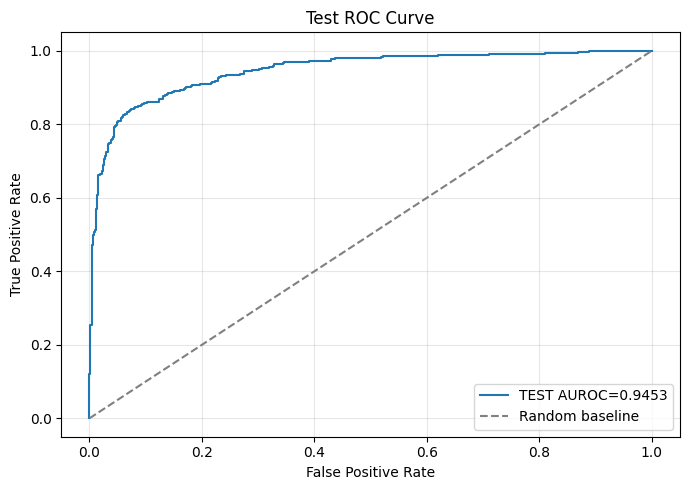

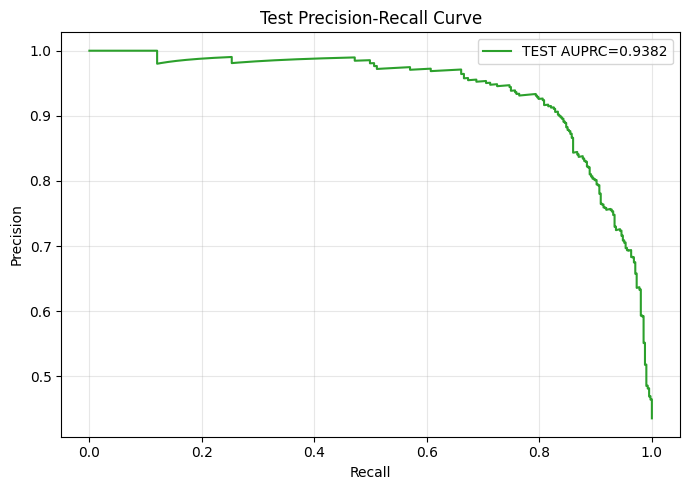

In [31]:
# This section plots ROC and precision-recall curves using the stored
# probabilities from ECoG section 3.

if "ecog_evaluation_outputs" not in globals():
    raise RuntimeError("Run ECoG section 3 first to generate evaluation outputs.")
if "ecog_ranking_metrics" not in globals():
    raise RuntimeError("Run ECoG section 5 first to generate AUROC/AUPRC summaries.")


ecog_curve_data = {}

for split_name, split_outputs in ecog_evaluation_outputs.items():
    y_true = split_outputs["y_true"]
    y_prob = split_outputs["y_prob"]

    fpr, tpr, roc_thresholds = roc_curve(y_true, y_prob)
    precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_true, y_prob)

    ecog_curve_data[split_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "roc_thresholds": roc_thresholds,
        "precision": precision_curve,
        "recall": recall_curve,
        "pr_thresholds": pr_thresholds,
    }


# Combined ROC curves across splits
plt.figure(figsize=(7, 5))
for split_name in ["train", "val", "test"]:
    split_curves = ecog_curve_data[split_name]
    split_auroc = ecog_ranking_metrics[split_name]["auroc"]
    plt.plot(split_curves["fpr"], split_curves["tpr"], label=f"{split_name.upper()} AUROC={split_auroc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Fine-Tuned ECoG PatchTST")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Combined precision-recall curves across splits
plt.figure(figsize=(7, 5))
for split_name in ["train", "val", "test"]:
    split_curves = ecog_curve_data[split_name]
    split_auprc = ecog_ranking_metrics[split_name]["auprc"]
    plt.plot(split_curves["recall"], split_curves["precision"], label=f"{split_name.upper()} AUPRC={split_auprc:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves for Fine-Tuned ECoG PatchTST")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Dedicated test ROC curve
test_curve_data = ecog_curve_data["test"]
test_auroc = ecog_ranking_metrics["test"]["auroc"]
plt.figure(figsize=(7, 5))
plt.plot(test_curve_data["fpr"], test_curve_data["tpr"], color="tab:blue", label=f"TEST AUROC={test_auroc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Test ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Dedicated test precision-recall curve
test_auprc = ecog_ranking_metrics["test"]["auprc"]
plt.figure(figsize=(7, 5))
plt.plot(test_curve_data["recall"], test_curve_data["precision"], color="tab:green", label=f"TEST AUPRC={test_auprc:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Test Precision-Recall Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
